In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

In [2]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [3]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [4]:
class State(TypedDict):
    topic: str  
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [5]:
# llm = ChatOpenAI(model="gpt-4.1-mini")
import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY") 

llm=ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [6]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [7]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [8]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [9]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


In [10]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

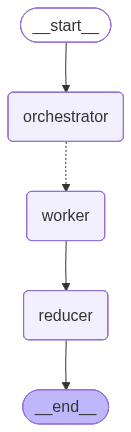

In [11]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [13]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

In [14]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: The Core of Modern Deep Learning', tasks=[Task(id=1, title='Introduction to Attention Mechanisms', brief='Explain the motivation behind attention, its historical context, and why self-attention is a pivotal advancement.'), Task(id=2, title='The Mathematics of Self-Attention', brief='Break down the query, key, value formulation, scaling factor, softmax, and the final weighted sum with clear equations.'), Task(id=3, title='Self-Attention in the Transformer Architecture', brief='Show how self-attention fits into encoder and decoder blocks, multi‑head attention, and positional encoding.'), Task(id=4, title='Benefits Over Traditional RNN/CNN Approaches', brief='Compare parallelism, long‑range dependency capture, and computational trade‑offs with concrete examples.'), Task(id=5, title='Practical Implementation Tips', brief='Provide code snippets (e.g., PyTorch/TensorFlow), memory‑efficient tri